# SLEEPY Tutorial
*Spins in Liouville space for rElaxation and Exchange in PYthon*

## Why another simulation program?
SLEEPY is NMR simulation software that is focused on simplifying simulations under dynamic conditions, where dynamics effects are introduced via exchange processes that stochastically modulate terms in the Hamiltonian. These are the types of processes that lead to *relaxation*: $T_1$, $T_2$, $T_{1\rho}$, NOE, etc. We think relaxation is important, so we wanted to make it easier to simulate it!

### How does it compare to other software?
* [SIMPSON](https://inano.au.dk/about/research-centers-and-projects/nmr/software/simpson)

  Compared to SIMPSON, SLEEPY will almost always be slower, and for good reason. SLEEPY operates in *Liouville space*, which requires matrices significantly larger than the *Hilbert space* matrices used in SIMPSON, e.g. when the Hilbert space matrix is $m\times m$, the Liouville space matrix is $m^2\times m^2$. This is the cost of including exchange, which cannot be introduced easily in Hilbert space. SLEEPY was designed to accept similar inputs as SIMPSON, although this happens now in a Python (ideally interactive!) environment rather than TCL.
  

* [Spinach](https://spindynamics.org/?page_id=12)

  Spinach is a general purpose NMR simulation software running in MATLAB, with full relaxation and dynamics capabilities. We guess that if you can simulate it in SLEEPY, it should also be possible in Spinach. We'd also bet that the same simulation in SLEEPY and Spinach would require a lot less coding in SLEEPY. SLEEPY is also more focused on interacive coding, i.e. create a code object, possibly inspect it, and combined it with other code objects to create a simulation. Still, Spinach can address a wider range of problems than SLEEPY. 
  

* [SpinEvolution](https://spinevolution.com/)

  SpinEvolution is fast, powerful software for NMR dynamics simulations. It is also behind a significant paywall, where dynamics simulations require a $1650 annual subscription. We think SLEEPY has a wider range of dynamics capabilities, but we weren't interested in paying the annual fee to make sure...
  

There's a lot else out there: these are just three of the most well-known. For getting familiar with dynamic effects, however, we think SLEEPY is a great place to start.

In [3]:
import sys
sys.path.append('/Users/albertsmith/Documents/GitHub.nosync/')

In [5]:
import SLEEPY as sl
import numpy as np
import matplotlib.pyplot as plt

**Python Tip:** A python program usually starts with module imports, see above. SLEEPY is the module we developed, which contains a lot of functions and objects used for simulating the impact of dynamics on NMR experiments. "sl" is the abbreviation we use for it in our code, which is just faster to type than SLEEPY. numpy is a module with lots of tools for doing matrix mathematics. matplotlib.pyplot is a submodule of Matplotlib for making nice plots. You can install and then import any module you like to use in combination with SLEEPY (e.g. import your experimental data with [nmrglue](http://127.0.0.1:8888/tree?token=524457c1a2cf549f68815e6adc33e11b78f1351c50be77f2) and then simulate it with SLEEPY within one Python terminal). numpy and pyplot are very frequently for scientific purposes, and so most of our scripts include importing these. Functions and classes found within a module are accessed by typing the module abbreviation followed by a period (.), and ending with the desired function/class/etc. from the module. For example, below we access the physical constants used in SLEEPY.

In [6]:
sl.Constants

{'h': 6.62607015e-34,
 'kB': 1.380649e-23,
 'mub': -13996244936.072704,
 'ge': 2.0023193043609235,
 'mun': 7622593.158495312,
 'mu0': 1.256637e-06}

## Example 1: Chemical Exchange
Chemical exchange is perhaps the simplest dynamics example in NMR. We have a molecule that changes structure, resulting in the modulation of the chemical shift between two or more states. If this process is fast, then only one peak appears at the averaged chemical shift, and if it is slow, two peaks arise, one for each chemical shift. If the process approximately matches the chemical shift difference, then a broad peak arises.

### Define the experimental conditions
The ExpSys *[class](https://en.wikipedia.org/wiki/Class_(programming))* defines [objects](https://en.wikipedia.org/wiki/Object_(computer_science)) which contain information about the experimental conditions. For example:
* Magnetic field (`ex.B0`)
* Nuclei (`ex.Nucs`)
* Spinning speed (`ex.vr`)
* Spins (`ex.S`)
* Temperature (`ex.T`)
* Interactions (`ex.CS` gives a list of chemical shifts)
* Spin operators (`ex.Op`: index first to select spin, then gives x, y, z, etc.)

In [9]:
ex=sl.ExpSys(v0H=500,Nucs=['1H'])  #Magnetic field, Nuclei in system
ex.set_inter('CS',i=0,Hz=500)      #Interaction type, spin index (use i0,i1 for spin-spin coupling)
                                   # Here, defined in Hz. Set ppm= to define via ppm

1-spin system (1H)
B0 = 11.743 T (500.000 MHz 1H frequency)
rotor angle = 54.736 degrees
rotor frequency = 10.0 kHz
Temperature = 298 K
Powder Average: JCP59 with 99 angles
Interactions:
	CS on spin 0 with arguments: (Hz=500.00)


Check various experimental parameters below. You can type `ex.` and then press the tab key to access autocompletions, or type `dir(ex)` to see all *attributes* of ex. Note, you'll access functions attached to the ExpSys object as well.

**Python tip:** Typing `dir(ex)` will reveal many attributes that start with one or two underscores (`_` or `__`), whereas tab will not. These are hidden variables (`_XXX`) or dunder methods (`__XXX__`). While you're welcome to explore what's in these variables, editing them directly has a good chance of breaking SLEEPY. That's why we hid them! For example, if you adjust `ex.rotor_angle`, SLEEPY will reset calculations of tensors in the lab frame, because these change with the rotor angle (if anisotropic interactions are present). If you adjust `ex._rotor_angle`, these resets won't occur and your simulation will be incorrect.

In [18]:
ex.rotor_angle

0.9553166181245093

Before we go on, we will check what the Hamitonian and Liouvillian look like. The Hamiltonian for a 1 spin-1/2 system is a pretty simple 2x2 matrix, whereas the Liouvillian expands into a 4x4 matrix. This Hamiltonian only leads to phase oscillation of the coherences, so we only obtain two non-zero values on the Liouvillian diagonal.

<AxesSubplot:>

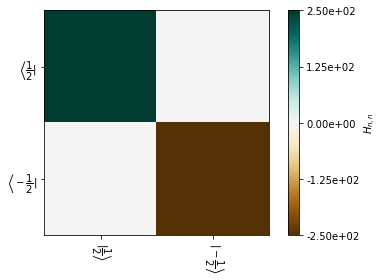

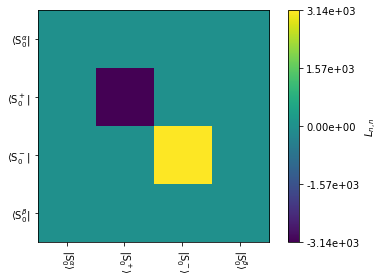

In [22]:
H=ex.Hamiltonian()  #Create the Hamiltonian
H.plot(mode='re')   #Plot the Hamiltonian, real part (most SLEEPY objects have some kind of plotting)
L=ex.Liouvillian()  #Create the Liouvillian
L.plot(mode='im')   #Plot the Liouvillian, imaginary part

### Add dynamics
To add dynamics, we first need something to change! So, we define a second ExpSys object with a different chemical shift. Rather than retyping all the experimental systems, we copy the first ExpSys object (`ex1=ex.copy()`). This saves us some time, but also links together some properties of the systems in case you decide to change something.

In [24]:
ex1=ex.copy()
_=ex1.set_inter('CS',i=0,Hz=100)  #Suppress text output by setting equal to _

Now, we combine the two systems into a Liouvillian, and plot the result

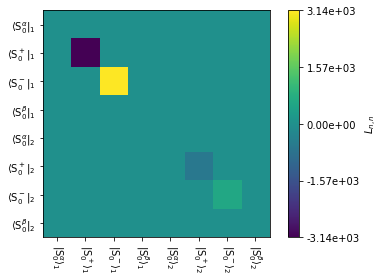

In [26]:
L=sl.Liouvillian(ex,ex1)
_=L.plot(mode='im')

The upper right contains the first Liouvillian, and the lower left contains the second. But, we're not done, because we'd like these to exchange. This is achieved by setting the exchange matrix for the Liouvillian. Since we have two states in exchange, the exchange matrix must be $2\times2$. The exchange matrix should also be mass-conserving, i.e. the columns should sum to zero, and should usually obey detailed balance except in special cases.

SLEEPY provides a number of functions for generating exchange matrices. Here, we use the `twoSite_kex` function in `Tools`, which takes a correlation time, `tc`, and an optional `p1` argument for the population of state 1 (defaults to 0.5).

Once we have added exchange, we plot again. Here, we use the absolute value, since the exchange part will be real and the coherent part imaginary. Then, we can see all terms in our plot, but we lose the sign of terms.

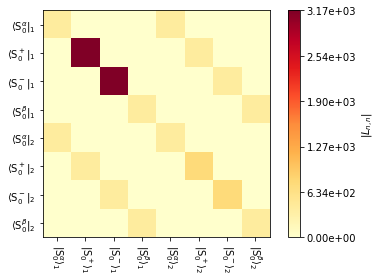

In [29]:
t_coal=1/(2*np.pi*(500-100))  #Correlation time for ca
L.kex=sl.Tools.twoSite_kex(tc=t_coal*3) #Puts us just into the slow-exchange regime.
_=L.plot(mode='abs')

The off-diagonal terms are introduced by the exchange matrix. Note what they do: they link $S_0^\alpha$ in the upper left to $S_0^\alpha$ in the lower right, for example. So exchange doesn't change the state of the system, it changes the conditions of the system given by the Liouvillian.

### Propagate the system
In order to propagate the system, we first need something to propagate! We generate a density matrix, `rho`. In SLEEPY, we must decide what state to start the system in when `rho` is generated, but also what to detect. Text-based arguments are accepted, e.g. `1Hx` would start all $^{1}$H in the system along the x-direction. We can also start on a specific spin, e.g. `S0z` would start in the z-direction on the 0$^th$ spin (first spin, but according to Python tradition, we number from zero). We often detect the $\hat{S}^+$ if we want to simulate spectra.

*Note:* SLEEPY also accepts explicit spin-matrices, which lets the user start in and detect arbitrary states of the spin-system, such as zero/double-quantum coherences, spin-order, etc.

In [38]:
rho=sl.Rho(rho0='S0x',detect='S0p')

We then generate a propagator, `U`. We need to decide how long it should be. If we use spinning, then propagators will have a default length of one rotor period, but here, spinning was automatically turned off because we do not have any interactions that are affected by it.

Here, we generate U directly from the Liouvillian. Note that this approach does not allow use to apply radio-frequency irradiation.

In [39]:
U=L.U(Dt=1/(4*500)) 
#500 Hz is the largest chemical shift, so this time step will be short enough to avoid backfolding it.

To get a spectrum, we have to detect the state of the system, then propagate, then detect, and so on. Detection in SLEEPY is done by *calling* the density matrix, i.e. `rho()`. Propagation is done by simply multiplying by a propagator.

In [40]:
for k in range(1024):  #Run k over 1024 steps
    rho()     #Detect
    U*rho     #Propagate for a time Dt

Now, rho contains the signal for 1024 time points (`rho.I`). It also calculates the time from the beginning of the experiment of each detection (`rho.t_axis`). It also has the Fourier transformed signal (`rho.FT`), and the corresponding frequency axis (`rho.v_axis`). The user may use these for plotting or other further analysis. However, if we would just like to see the spectrum, we can run `rho.plot(FT=True)`, where `FT` determines whether to Fourier Transform the signal for a spectrum (`True`) or just show the time-trace (`False`).

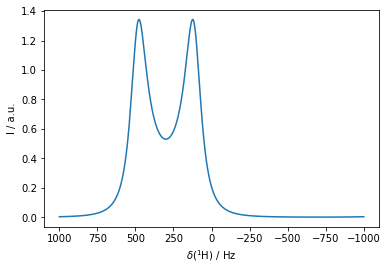

In [42]:
_=rho.plot(FT=True)

The for-loop above can be made more convenient. To demonstrate, we first clear the data out of `rho`, and then use the built-in `DetProp` function.

State-space reduction: 8->2


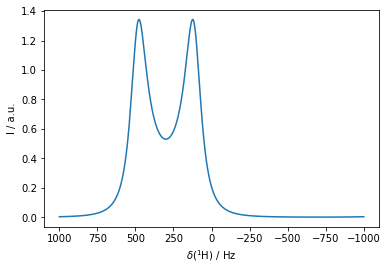

In [43]:
rho.clear()
rho.DetProp(U,n=1024)
_=rho.plot(FT=True)

The result is the same. `DetProp` is not only less to type, but it is also more efficient: it automatically reduces the matrix size wherever possible (see the message above: *State-space reduction: 8->2*, means that the 8x8 matrices were replaced with 2x2 matrices). It also uses eigenbasis propagation, which avoids a large number of matrix multiplications. Here we don't notice such a difference, but these features become critical elsehwere. Note that some experiments, however, for example REDOR, need to be done with the for-loop.

### Modify dynamics to view results

State-space reduction: 8->2
State-space reduction: 8->2
State-space reduction: 8->2
State-space reduction: 8->2
State-space reduction: 8->2


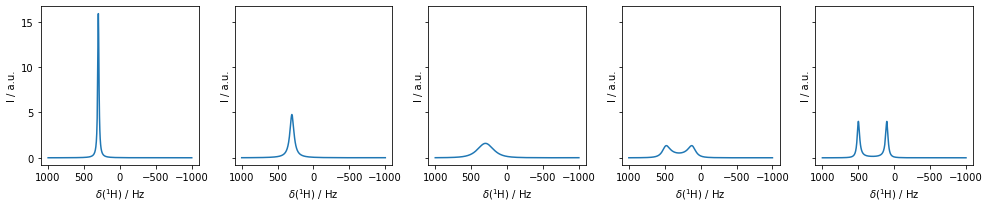

In [46]:
tc0=[t_coal/10,t_coal/3,t_coal,t_coal*3,t_coal*10]  #5 correlation times
fig,ax=plt.subplots(1,5,figsize=[14,3],sharey=True) #Creates figure with 5 axes to plot into
for tc,a in zip(tc0,ax):
    L.kex=sl.Tools.twoSite_kex(tc=tc)  #Reset the exchange matrix
    U=L.U(Dt=1/(4*500))
    rho.clear()  #Clear the density matrix
    rho.DetProp(U,n=1024)
    rho.plot(FT=True,ax=a)  #ax=a tells it where to plot the figure
fig.tight_layout()

### How much code is required?
For just one simulation? Not much...

State-space reduction: 8->2


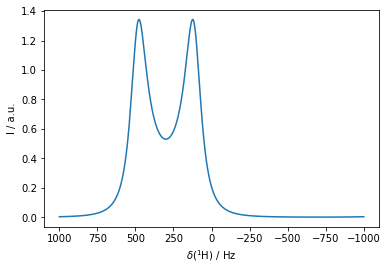

In [59]:
ex=sl.ExpSys(v0H=500,Nucs=['1H'])  #Basic settings
ex.set_inter('CS',i=0,Hz=500)      #Interactions
ex1=ex.copy()                      #Exchanging system
ex1.set_inter('CS',i=0,Hz=100)
L=sl.Liouvillian(ex,ex1,kex=sl.Tools.twoSite_kex(tc=3*t_coal)) #Build Liouvillian
U=L.U(Dt=1/(4*500))                #Propagator
rho=sl.Rho(rho0='S0x',detect='S0p')
rho.DetProp(U,n=1024)
_=rho.plot(FT=True)

**A somewhat useless object-oriented programming trick:**

*Do the whole simulation in one really long line of code:*

State-space reduction: 8->2


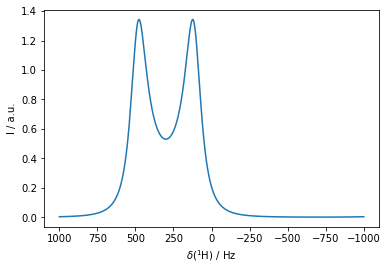

In [152]:
_=sl.Rho('S0x','S0p').DetProp(sl.Liouvillian(sl.ExpSys(500,Nucs='1H').set_inter('CS',i=0,Hz=500),
                                           sl.ExpSys(500,Nucs='1H').set_inter('CS',i=0,Hz=100),
                                           kex=sl.Tools.twoSite_kex(tc=3/(2*np.pi*400))).U(Dt=1/2000),
                                           n=1024).plot(FT=True)

## Example 2: $R_{1\rho}$ relaxation

A critical dynamics experiment in solid-state NMR is the $R_{1\rho}$ measurement (relaxation under a spin-lock). Information content is similar to the CPMG experiment. Here, we need to introduce two systems, where motion is induced by a hopping dipolar coupling and chemical shift anisotropy. We can also add chemical exchange.

In [143]:
delta=sl.Tools.dipole_coupling(.102,'15N','1H')  #Distance, nuc1, nuc2
ex0=sl.ExpSys(v0H=500,Nucs=['15N','1H'],vr=60000,pwdavg='rep320')
ex0.set_inter('dipole',i0=0,i1=1,delta=delta)
ex0.set_inter('CSA',i=0,delta=113,euler_d=[0,23,0])
ex0.set_inter('CS',i=0,ppm=-5)
ex1=ex0.copy()
ex1.set_inter('dipole',i0=0,i1=1,delta=delta,euler_d=[0,20,45])
ex1.set_inter('CSA',i=0,delta=113,euler_d=[[0,23,0],[0,20,45]])
_=ex1.set_inter('CS',i=0,ppm=5)

We can check what our motion looks like for the dipole and CSA couplings.

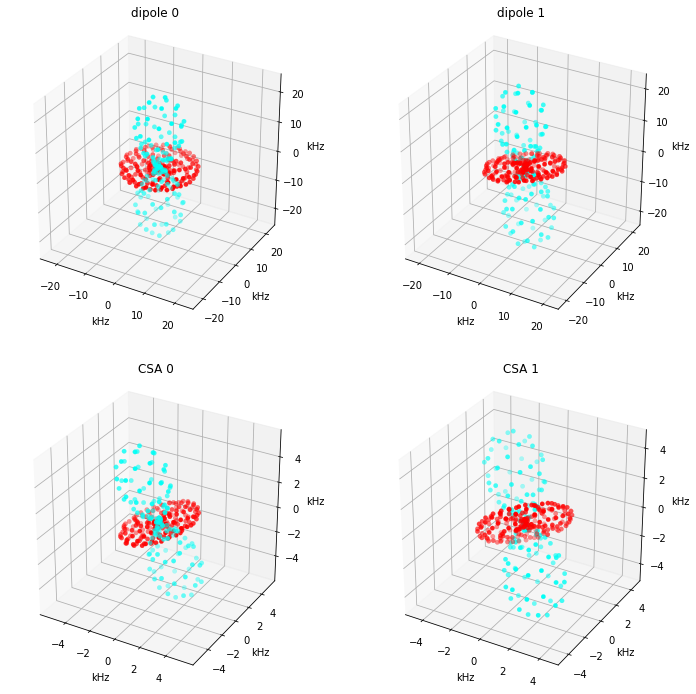

In [149]:
fig=plt.figure(figsize=[12,12])
ax=[[fig.add_subplot(2,2,2*k+m+1,projection='3d') for k in range(2)] for m in range(2)]
for k,(ex,ax0) in enumerate(zip([ex0,ex1],ax)):
    for q,(inter,a) in enumerate(zip(['dipole','CSA'],ax0)):
        ex.plot_inter(q,ax=a)
        a.set_title(f'{inter} {k}')

In [160]:
ex0.pwdavg=2 #We used a larger powder average above to make nicer plots
# Here, we reduce the size for calculations, since we don't really need a big average

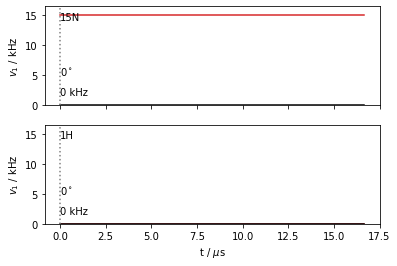

In [164]:
L=sl.Liouvillian(ex0,ex1,kex=sl.Tools.twoSite_kex(tc=1e-5))
seq=L.Sequence()
seq.add_channel('15N',v1=15000)
_=seq.plot()

<AxesSubplot:xlabel='t / ms', ylabel='<$^{15}N_x$>'>

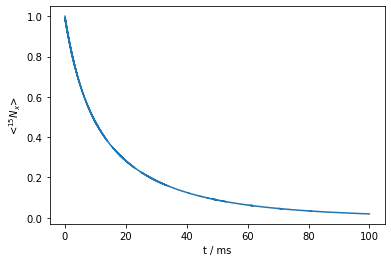

In [165]:
rho=sl.Rho('15Nx','15Nx')
rho.DetProp(seq,n=6000)
rho.plot()

### Check field-strength dependence

In [166]:
sl.Defaults['verbose']=False
v10=np.linspace(100,56100,29)
R1p=[]
rho=sl.Rho('15Nx','15Nx')
for v1 in v10:
    print(v1)
    seq.add_channel('15N',v1=v1)
    R1p.append(rho.extract_decay_rates(seq))

100.0
2100.0
4100.0
6100.0
8100.0
10100.0
12100.0
14100.0
16100.0
18100.0
20100.0
22100.0
24100.0
26100.0
28100.0
30100.0
32100.0
34100.0
36100.0
38100.0
40100.0
42100.0
44100.0
46100.0
48100.0
50100.0
52100.0
54100.0
56100.0


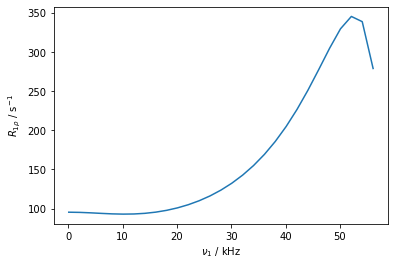

In [167]:
ax=plt.subplots()[1]
ax.plot(v10/1e3,R1p)
ax.set_xlabel(r'$\nu_1$ / kHz')
_=ax.set_ylabel(r'$R_{1\rho}$ / s$^{-1}$')

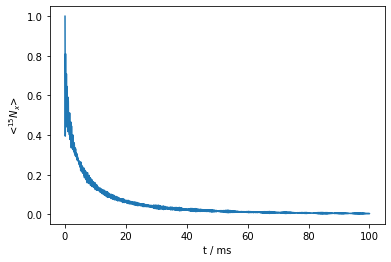

In [180]:
ax=rho.DetProp(seq,n=6000).plot()

In [177]:
R=rho.clear().extract_decay_rates(seq)

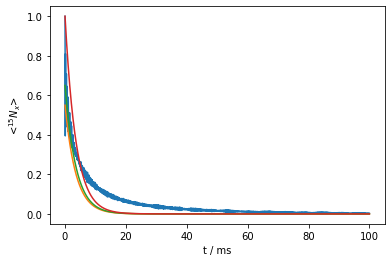

In [183]:
ax.plot(rho.t_axis*1e3,np.exp(-R*rho.t_axis))
ax.figure